# Phase 1: Exploratory Data Analysis (EDA) & Data Quality 

**Goal**: Deeply understand the Volatility Forecasting dataset before any modeling.

*This data spans `2010-01-01` to `2026-03-30` covering highly volatile historical periods including the 2024-2026 regimes.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')
from src.utils.config import cfg
from src.data.loader import DataLoader
from src.data.preprocessing import VolatilityProcessor

# Setup plot style
plt.style.use(cfg.viz.style)
sns.set_palette("tab10")

## 1. Data Overview
Let's load the data using our `DataLoader` and check for missing values, shape, and structure.

In [2]:
loader = DataLoader() # Config is automatically applied via singletons
dfs = {
    'Stock': loader.load('stock'),
    'ETF': loader.load('etf'),
    'Forex': loader.load('forex'),
    'Crypto': loader.load('crypto')
}

summary = []
for name, df in dfs.items():
    summary.append({
        'Asset Class': name,
        'Rows': len(df),
        'Tickers': df['Ticker'].nunique(),
        'Min Date': df['Date'].min(),
        'Max Date': df['Date'].max(),
        'Missing Close': df['Close'].isna().sum()
    })
    
summary_df = pd.DataFrame(summary)
display(summary_df)

2026-03-31 05:35:21 | INFO     | src.data.loader | Loading stock data from: /home/thota23/Volatility-Forecasting-in-Global-Financial-Markets-Using-TimeMixer/Data/stock.csv


2026-03-31 05:35:21 | INFO     | src.data.loader |   ✓ stock: 58,259 rows | 10 tickers | 2010-01-04 → 2026-03-30


2026-03-31 05:35:21 | INFO     | src.data.loader | Loading etf data from: /home/thota23/Volatility-Forecasting-in-Global-Financial-Markets-Using-TimeMixer/Data/index_etf.csv


2026-03-31 05:35:21 | INFO     | src.data.loader |   ✓ etf: 57,865 rows | 10 tickers | 2010-01-04 → 2026-03-30


2026-03-31 05:35:21 | INFO     | src.data.loader | Loading forex data from: /home/thota23/Volatility-Forecasting-in-Global-Financial-Markets-Using-TimeMixer/Data/forex.csv


2026-03-31 05:35:21 | INFO     | src.data.loader |   ✓ forex: 59,330 rows | 10 tickers | 2010-01-01 → 2026-03-30


2026-03-31 05:35:21 | INFO     | src.data.loader | Loading crypto data from: /home/thota23/Volatility-Forecasting-in-Global-Financial-Markets-Using-TimeMixer/Data/crypto.csv


2026-03-31 05:35:21 | INFO     | src.data.loader |   ✓ crypto: 31,030 rows | 10 tickers | 2014-09-17 → 2026-03-29


,Asset Class,Rows,Tickers,Min Date,Max Date,Missing Close
0,Stock,58259,10,2010-01-04,2026-03-30,10
1,ETF,57865,10,2010-01-04,2026-03-30,10
2,Forex,59330,10,2010-01-01,2026-03-30,10
3,Crypto,31030,10,2014-09-17,2026-03-29,0


## 2. Price Series Visualizations
Plot the raw closing prices for a representative subset of assets.

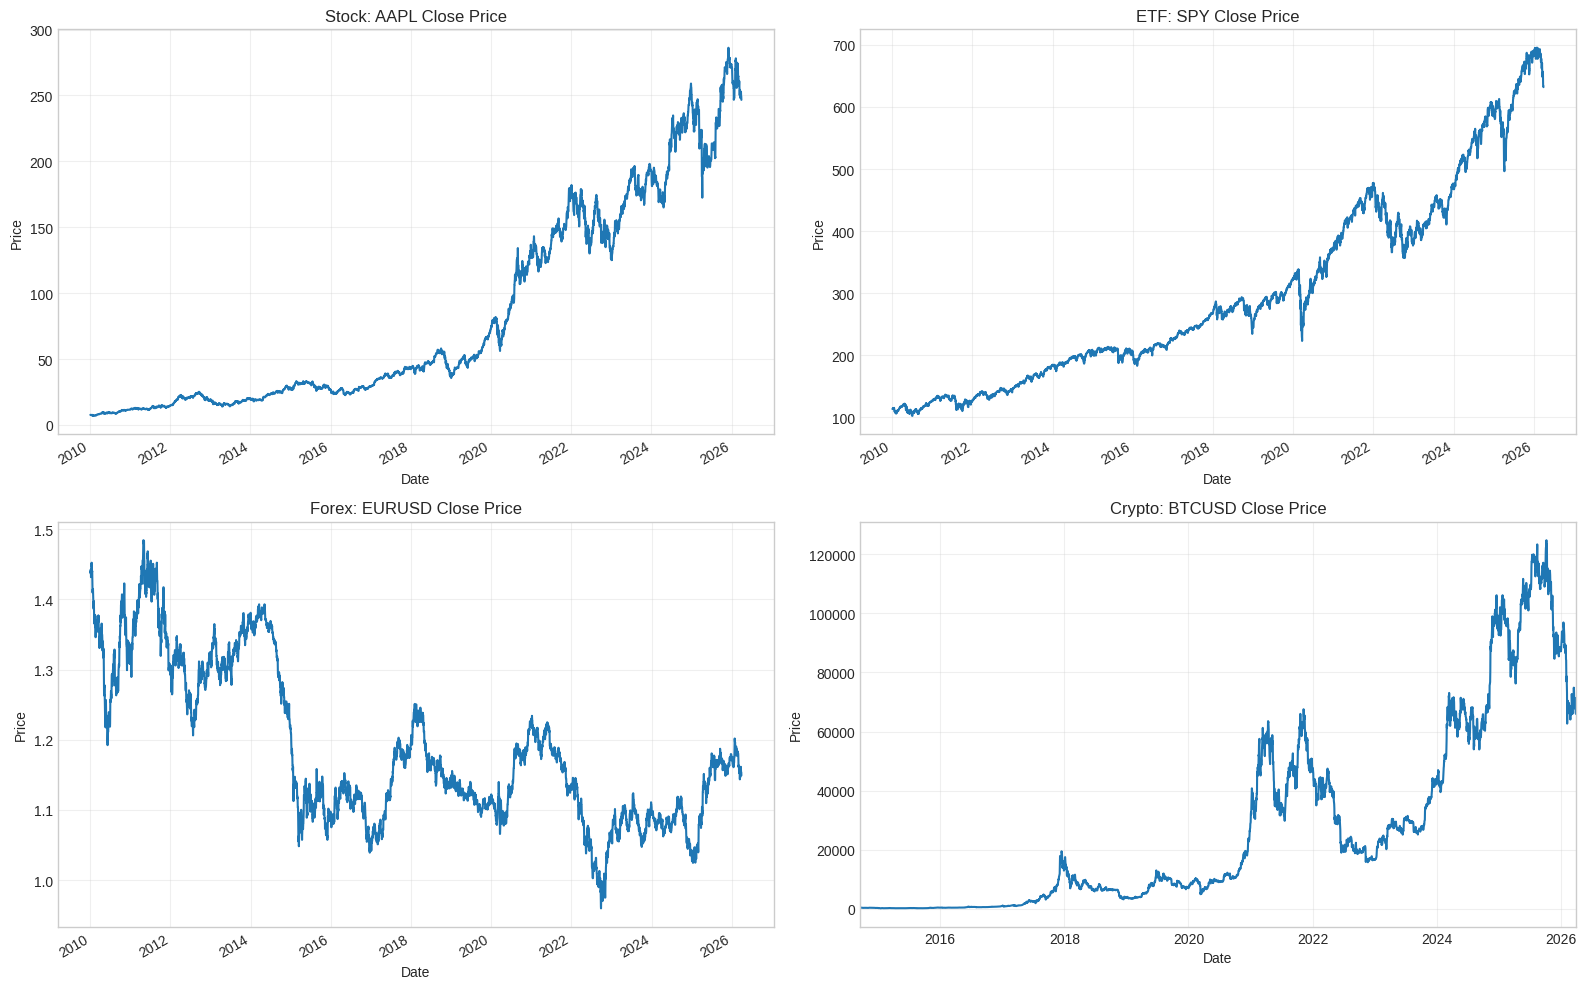

In [3]:
reps = {'Stock': 'AAPL', 'ETF': 'SPY', 'Forex': 'EURUSD', 'Crypto': 'BTCUSD'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (asset, ticker) in enumerate(reps.items()):
    df = dfs[asset]
    ticker_data = df[df['Ticker'] == ticker].sort_values('Date').set_index('Date')
    ticker_data['Close'].plot(ax=axes[i], title=f"{asset}: {ticker} Close Price")
    axes[i].set_ylabel("Price")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Volatility Deep Dive (Yang-Zhang)
We'll use our `VolatilityProcessor` to compute Yang-Zhang volatility, the rigorous target metric of our system. We highlight the `2024-2026` evaluation window.

2026-03-31 05:35:22 | INFO     | src.data.preprocessing | Computing volatility | window=21d | primary=Yang-Zhang


2026-03-31 05:35:22 | INFO     | src.data.preprocessing |   ✓ 58,039 rows | 10 tickers | cols: ['ds', 'yz_vol', 'rolling_vol', 'unique_id', 'y']


2026-03-31 05:35:22 | INFO     | src.data.preprocessing | Computing volatility | window=21d | primary=Yang-Zhang


2026-03-31 05:35:22 | INFO     | src.data.preprocessing |   ✓ 57,645 rows | 10 tickers | cols: ['ds', 'yz_vol', 'rolling_vol', 'unique_id', 'y']


2026-03-31 05:35:22 | INFO     | src.data.preprocessing | Computing volatility | window=21d | primary=Yang-Zhang


2026-03-31 05:35:22 | INFO     | src.data.preprocessing |   ✓ 59,110 rows | 10 tickers | cols: ['ds', 'yz_vol', 'rolling_vol', 'unique_id', 'y']


2026-03-31 05:35:22 | INFO     | src.data.preprocessing | Computing volatility | window=21d | primary=Yang-Zhang


2026-03-31 05:35:22 | INFO     | src.data.preprocessing |   ✓ 30,820 rows | 10 tickers | cols: ['ds', 'yz_vol', 'rolling_vol', 'unique_id', 'y']


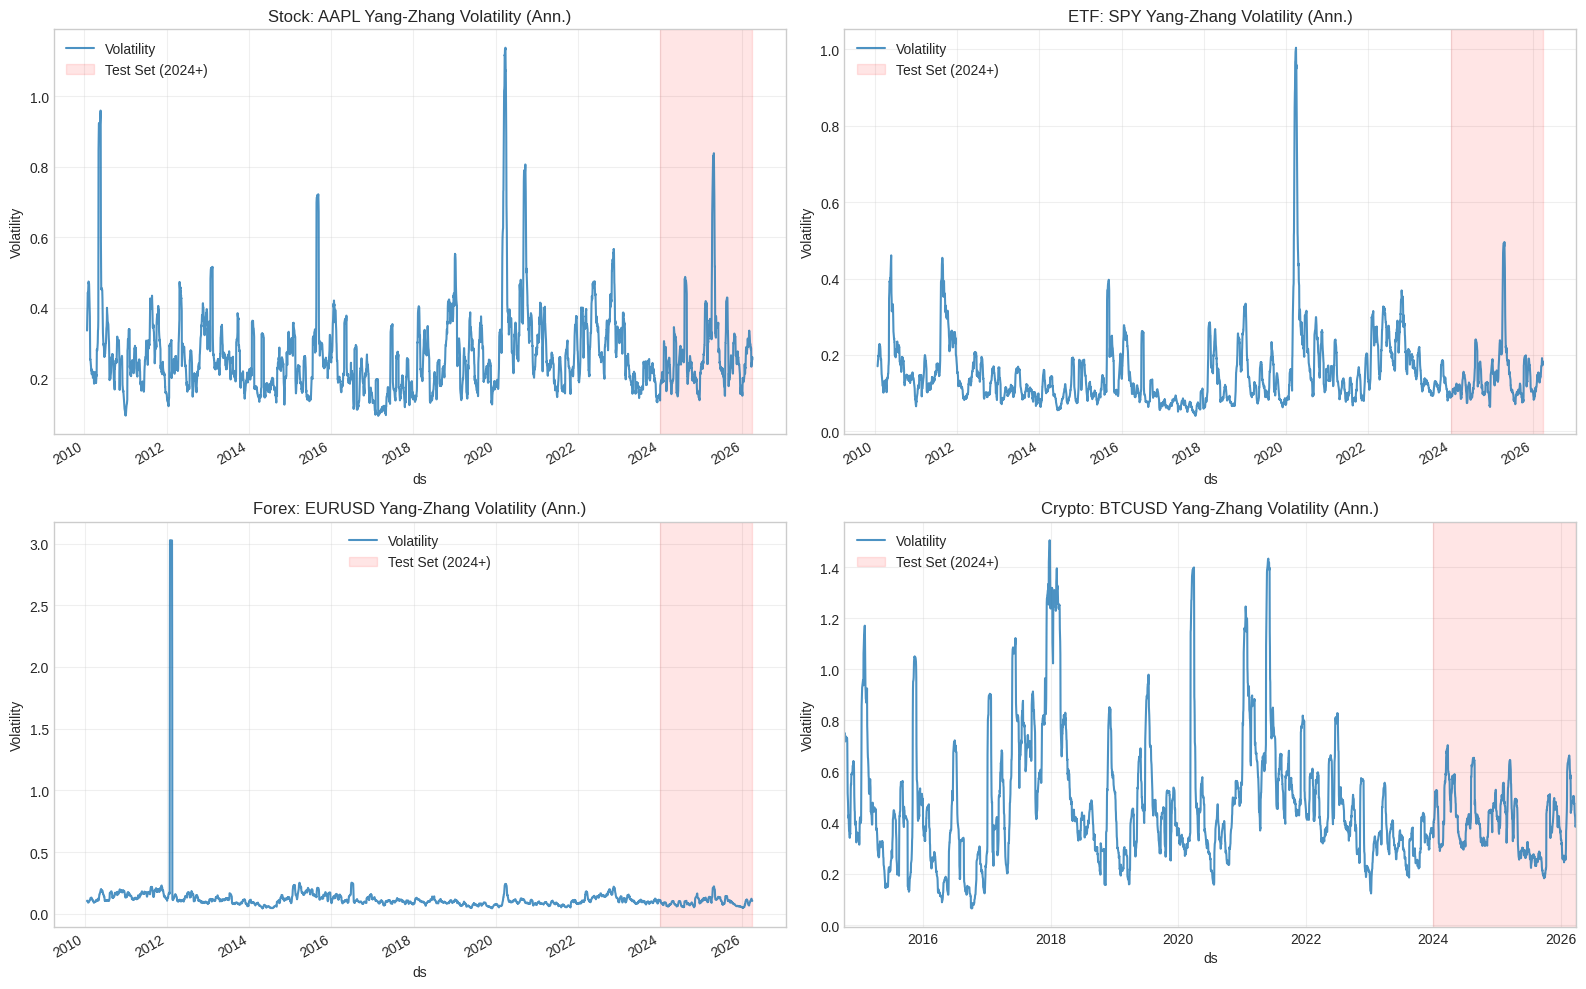

In [4]:
proc = VolatilityProcessor()
split_date = pd.to_datetime(cfg.data.split_date)

y_vol_dfs = {}
for name, df in dfs.items():
    # Compute volatility
    vol_df = proc.compute_volatility(df)
    y_vol_dfs[name] = vol_df

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (asset, ticker) in enumerate(reps.items()):
    v_df = y_vol_dfs[asset]
    ticker_vol = v_df[v_df['unique_id'] == ticker].sort_values('ds').set_index('ds')
    
    # Plot historical
    ticker_vol['y'].plot(ax=axes[i], label='Volatility', alpha=0.8)
    
    # Highlight test set
    axes[i].axvspan(split_date, ticker_vol.index.max(), color='red', alpha=0.1, label='Test Set (2024+)')
    
    axes[i].set_title(f"{asset}: {ticker} Yang-Zhang Volatility (Ann.)")
    axes[i].set_ylabel("Volatility")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Volatility Distribution and Auto-correlation (ACF)
Volatility tends to cluster. Let's see if the autocorrelation persists.

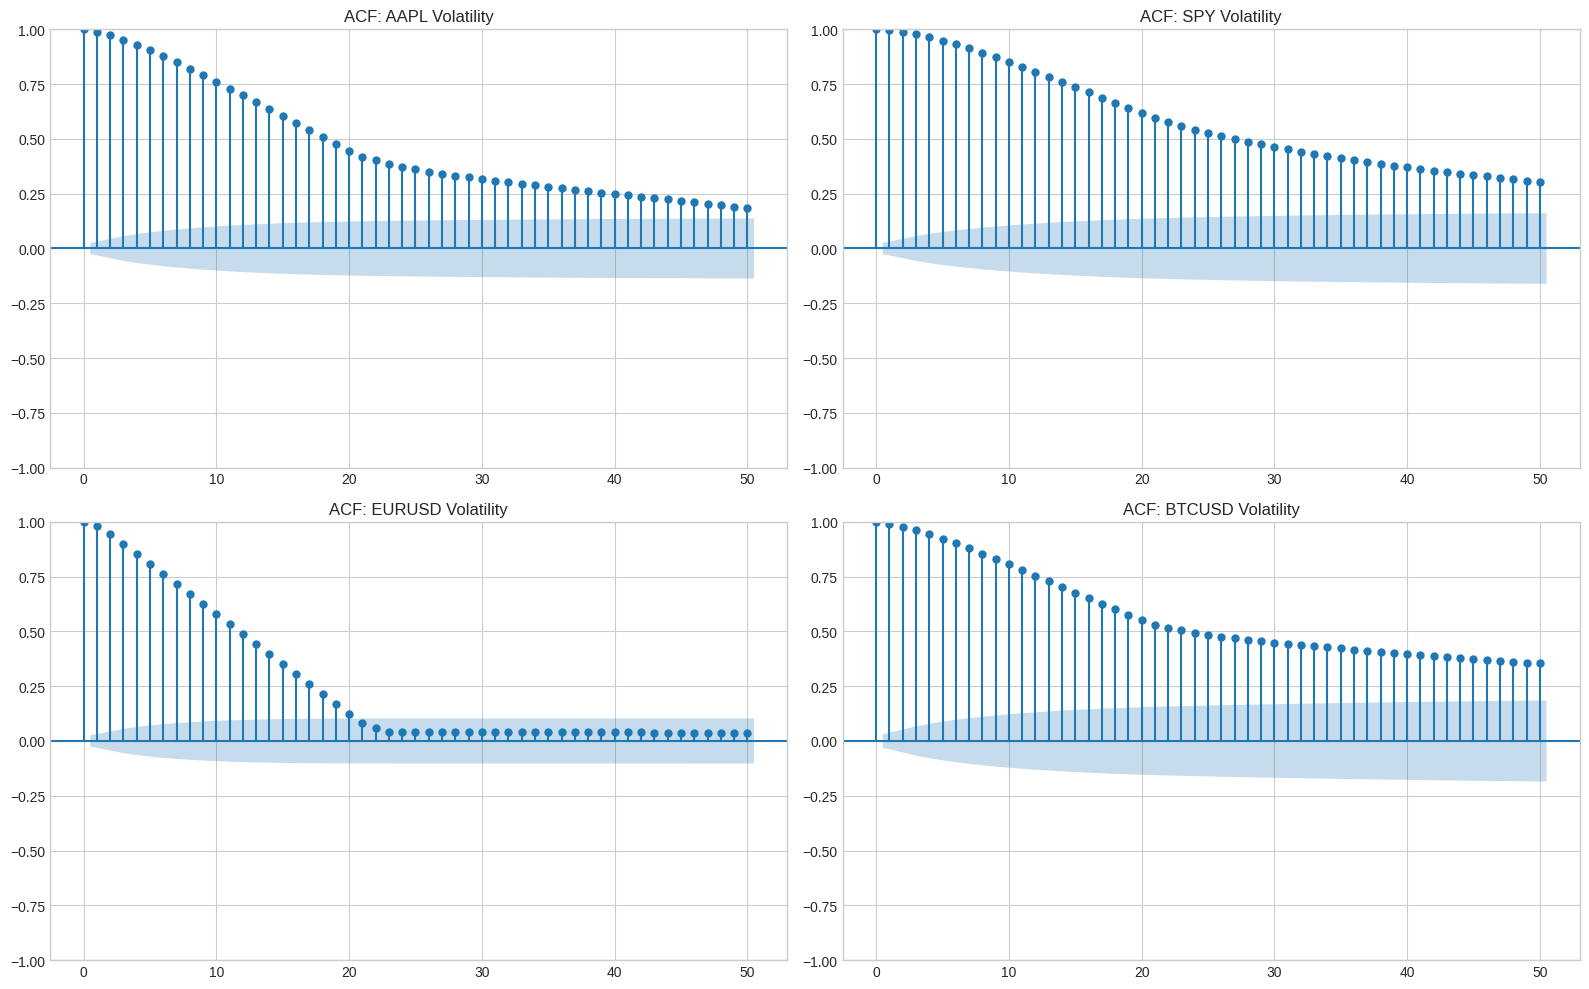

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (asset, ticker) in enumerate(reps.items()):
    v_df = y_vol_dfs[asset]
    ticker_vol = v_df[v_df['unique_id'] == ticker].sort_values('ds')['y'].dropna()
    plot_acf(ticker_vol, ax=axes[i], lags=50, title=f"ACF: {ticker} Volatility")

plt.tight_layout()
plt.show()

## 5. Cross-Asset Volatility Correlation
How do different assets correlate in terms of volatility?

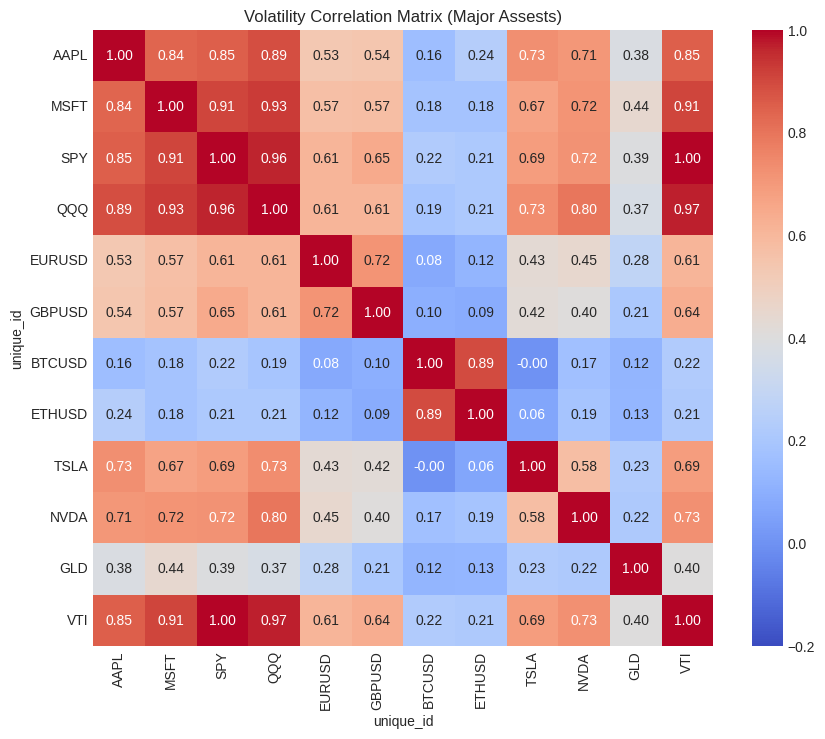

In [6]:
# Gather all YZ volatilties into a single DataFrame on matching dates
pivot_vols = []
for name, v_df in y_vol_dfs.items():
    pivot = v_df.pivot_table(index='ds', columns='unique_id', values='y')
    pivot_vols.append(pivot)

all_vols = pd.concat(pivot_vols, axis=1).dropna(how='all')

# Choose major tickers for correlation
subset_tickers = ['AAPL', 'MSFT', 'SPY', 'QQQ', 'EURUSD', 'GBPUSD', 'BTCUSD', 'ETHUSD', 'TSLA', 'NVDA', 'GLD', 'VTI']
subset_vols = all_vols[[c for c in subset_tickers if c in all_vols.columns]].dropna()

plt.figure(figsize=(10, 8))
sns.heatmap(subset_vols.corr(), annot=True, cmap='coolwarm', vmin=-0.2, vmax=1.0, fmt='.2f')
plt.title("Volatility Correlation Matrix (Major Assests)")
plt.show()

## 6. Executive Summary
- **Completeness:** Data up to `March 2026` provides excellent coverage, with crypto containing the deepest complete 2024-2026 test-set structure.
- **Volatility Regimes:** The red highlighted region (test-set starting `2024-01-01`) contains significant volatility variation, making it an excellent robust trial ground for the TimeMixer.
- **Clustering:** ACF plots confirm strong volatility persistence across all assets (decaying slowly), an absolute requirement for successful forecasting.
- **Correlations:** Crypto correlates well with crypto, Stocks with ETFs. This supports training TimeMixer potentially with multi-variate setups if we pursue it.